<a href="https://colab.research.google.com/github/Supriya6462/AI-and-Machine-Learning/blob/main/RacistSexistdataset_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1 · Install & Import Dependencies

In [1]:
!pip install numpy==1.26.4 pandas==2.2.2 scipy==1.13.1
!pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0
!pip install tensorflow==2.17.0
!pip install ml_dtypes==0.5.1 jax==0.4.30 jaxlib==0.4.30
!pip install contractions wordcloud gensim gradio --quiet

  Using cached ml_dtypes-0.4.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached ml_dtypes-0.4.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.2 MB)
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.1
    Uninstalling ml_dtypes-0.5.1:
      Successfully uninstalled ml_dtypes-0.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.17.0 which is incompatible.
optax 0.2.8 requires jax>=0.5.3, but you have jax 0.4.30 which is incompatible.
optax 0.2.8 requires jaxlib>=0.5.3, but you have jaxlib 0.4.30 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.17.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.17.0 wh

In [2]:
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
import ml_dtypes
import jax

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)
print("ml_dtypes:", ml_dtypes.__version__)
print("JAX:", jax.__version__)

NumPy: 1.26.4
Pandas: 2.2.2
Scikit-learn: 1.3.2
TensorFlow: 2.17.0
ml_dtypes: 0.5.1
JAX: 0.4.30


In [3]:
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                      Bidirectional, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import gensim.downloader as api

# Download NLTK assets
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print('TensorFlow version:', tf.__version__)
print('All dependencies loaded successfully.')

TensorFlow version: 2.17.0
All dependencies loaded successfully.


## 2 · Load Dataset

In [5]:
# Paths
TRAIN_PATH = '/content/drive/MyDrive/AI\ML/DATA/Racist Sexist or not dataset/train_racisit.csv'
TEST_PATH  = '/content/drive/MyDrive/AI\ML/DATA/Racist Sexist or not dataset/test_racisit.csv'
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print('Train shape:', train_df.shape)
print('Test  shape:', test_df.shape)
print()
print(train_df.head())

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_7630/1300327956.py:2: SyntaxWarning: invalid escape sequence '\M'
  TRAIN_PATH = '/content/drive/MyDrive/AI\ML/DATA/Racist Sexist or not dataset/train_racisit.csv'
/tmp/ipykernel_7630/1300327956.py:3: SyntaxWarning: invalid escape sequence '\M'
  TEST_PATH  = '/content/drive/MyDrive/AI\ML/DATA/Racist Sexist or not dataset/test_racisit.csv'


Train shape: (31962, 3)
Test  shape: (17197, 2)

   id  label                                              tweet
0   1      0   @user when a father is dysfunctional and is s...
1   2      0  @user @user thanks for #lyft credit i can't us...
2   3      0                                bihday your majesty
3   4      0  #model   i love u take with u all the time in ...
4   5      0             factsguide: society now    #motivation


In [6]:
# Basic info
print('Train columns :', train_df.columns.tolist())
print('Missing values:\n', train_df.isnull().sum())
print()
print('Class distribution (train):')
print(train_df['label'].value_counts())
print()
print('Class balance (%):')
print(train_df['label'].value_counts(normalize=True).mul(100).round(2))

Train columns : ['id', 'label', 'tweet']
Missing values:
 id       0
label    0
tweet    0
dtype: int64

Class distribution (train):
label
0    29720
1     2242
Name: count, dtype: int64

Class balance (%):
label
0    92.99
1     7.01
Name: proportion, dtype: float64


## 3 · Exploratory Data Analysis

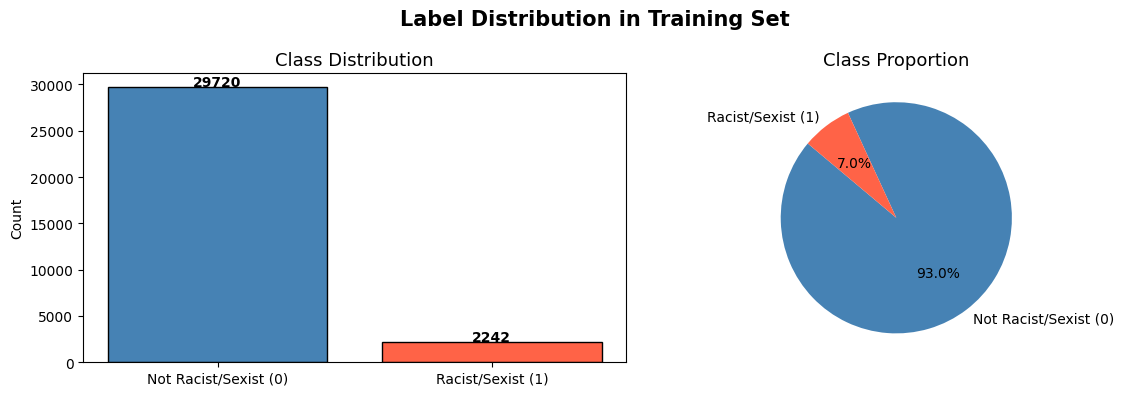

Imbalance ratio: 13.3 : 1


In [20]:
# 3.1 Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = train_df['label'].value_counts()
label_names  = {0: 'Not Racist/Sexist (0)', 1: 'Racist/Sexist (1)'}

axes[0].bar(
    [label_names[l] for l in label_counts.index],
    label_counts.values,
    color=['steelblue', 'tomato'], edgecolor='black'
)
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=[label_names[l] for l in label_counts.index],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=140
)
axes[1].set_title('Class Proportion', fontsize=13)

plt.suptitle('Label Distribution in Training Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Imbalance ratio: {label_counts[0] / label_counts[1]:.1f} : 1')

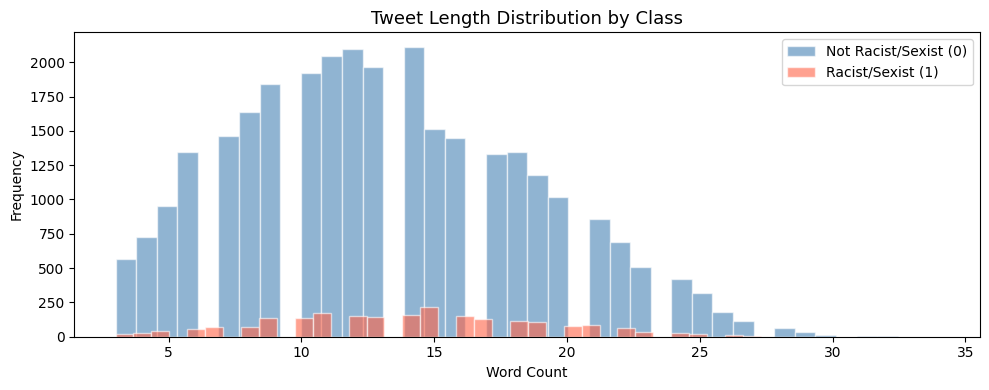

         count       mean       std  min   25%   50%   75%   max
label                                                           
0      29720.0  13.091252  5.510082  3.0   9.0  13.0  17.0  34.0
1       2242.0  14.053078  4.950747  3.0  10.0  14.0  17.0  30.0


In [19]:
# 3.2 Tweet length distribution
train_df['tweet_len'] = train_df['tweet'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
for lbl, color in zip([0, 1], ['steelblue', 'tomato']):
    subset = train_df[train_df['label'] == lbl]['tweet_len']
    plt.hist(subset, bins=40, alpha=0.6, color=color,
             label=label_names[lbl], edgecolor='white')

plt.title('Tweet Length Distribution by Class', fontsize=13)
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print(train_df.groupby('label')['tweet_len'].describe())

## 4 · Text Preprocessing

In [18]:
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def clean_tweet(text):
    """Tweet-aware text cleaner."""
    text = str(text).lower()

    # Expand contractions (e.g. "don't" → "do not")
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove @mentions (keep the word text but strip the '@')
    text = re.sub(r'@\w+', '', text)

    # Remove hashtag symbol but keep the word (may carry semantic signal)
    text = re.sub(r'#(\w+)', r'\1', text)

    # Remove RT (retweet marker)
    text = re.sub(r'\brt\b', '', text)

    # Remove numbers and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenise, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 1]

    return ' '.join(tokens)

# Apply to train and test
train_df['cleaned_tweet'] = train_df['tweet'].apply(clean_tweet)
test_df['cleaned_tweet']  = test_df['tweet'].apply(clean_tweet)

# Preview
pd.set_option('display.max_colwidth', 120)
print('Sample before vs after cleaning:')
train_df[['tweet', 'cleaned_tweet']].sample(5, random_state=1)

Sample before vs after cleaning:


,tweet,cleaned_tweet
266,i'll probably be 30 by the time @user comes back home #ugh,probably time come back home ugh
20460,just finished recoding my audition for abc dicovers. #abcdiscovers #abc #actorslife #sagaftra,finished recoding audition abc dicovers abcdiscovers abc actorslife sagaftra
18133,"this will be dustin's bihday present, bihday dj,",dustins bihday present bihday dj
15417,"this is my ""do i really have to go to work face""!!!! #work #face #itsfriday #wanttosleep",really go work face work face itsfriday wanttosleep
3077,eat the all #muslm,eat muslm


## 5 · Post-Cleaning Visualisations

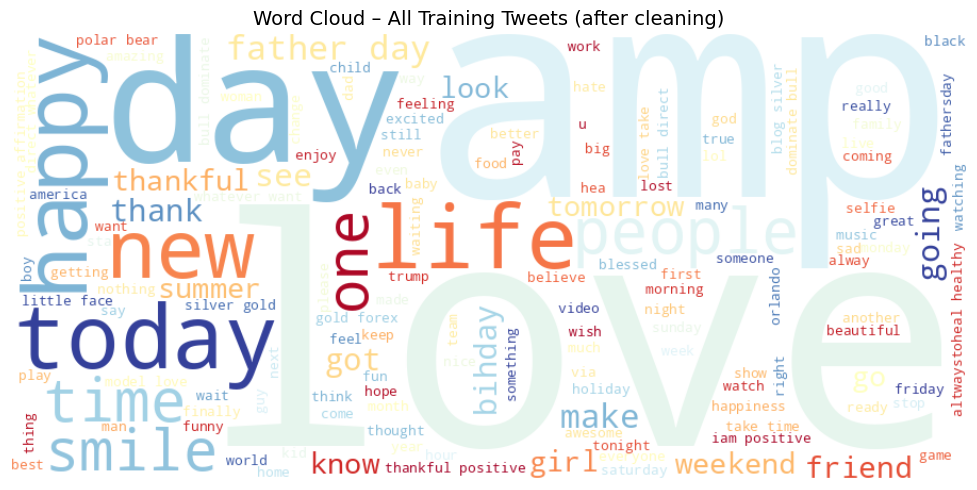

In [17]:
#  5.1 Word Cloud (all tweets)
all_text = ' '.join(train_df['cleaned_tweet'])

wc = WordCloud(width=900, height=420, background_color='white',
               colormap='RdYlBu', max_words=150).generate(all_text)

plt.figure(figsize=(13, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud – All Training Tweets (after cleaning)', fontsize=14)
plt.tight_layout()
plt.show()

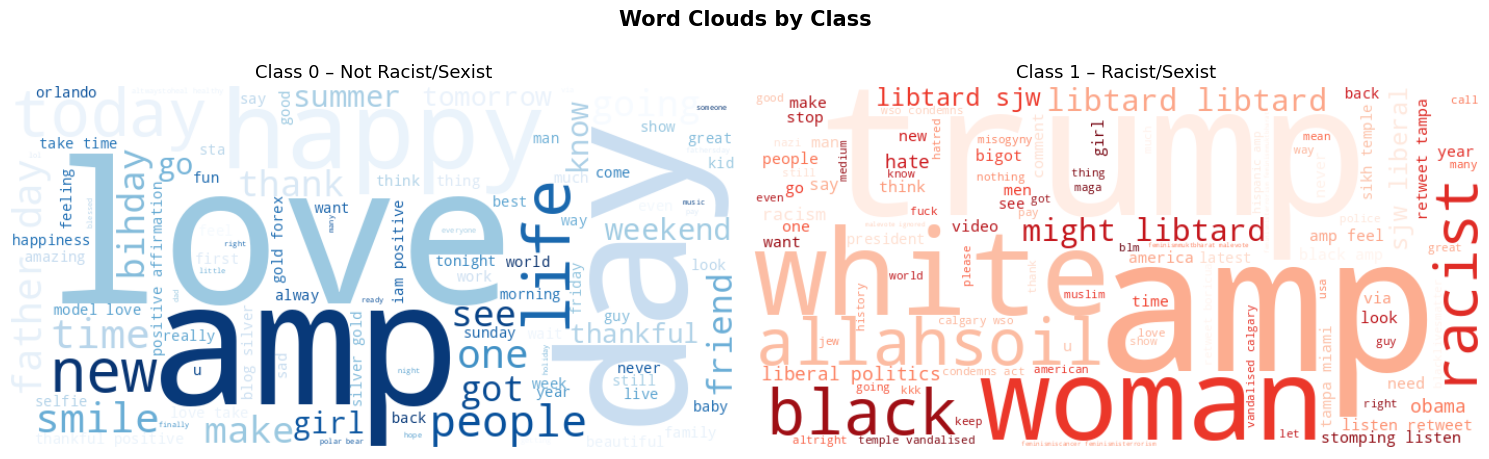

In [11]:
# 5.2 Word Clouds per class
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, lbl, cmap, title in zip(
        axes, [0, 1],
        ['Blues', 'Reds'],
        ['Class 0 – Not Racist/Sexist', 'Class 1 – Racist/Sexist']):

    txt  = ' '.join(train_df[train_df['label'] == lbl]['cleaned_tweet'])
    wc   = WordCloud(width=700, height=350, background_color='white',
                     colormap=cmap, max_words=100).generate(txt)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13)

plt.suptitle('Word Clouds by Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

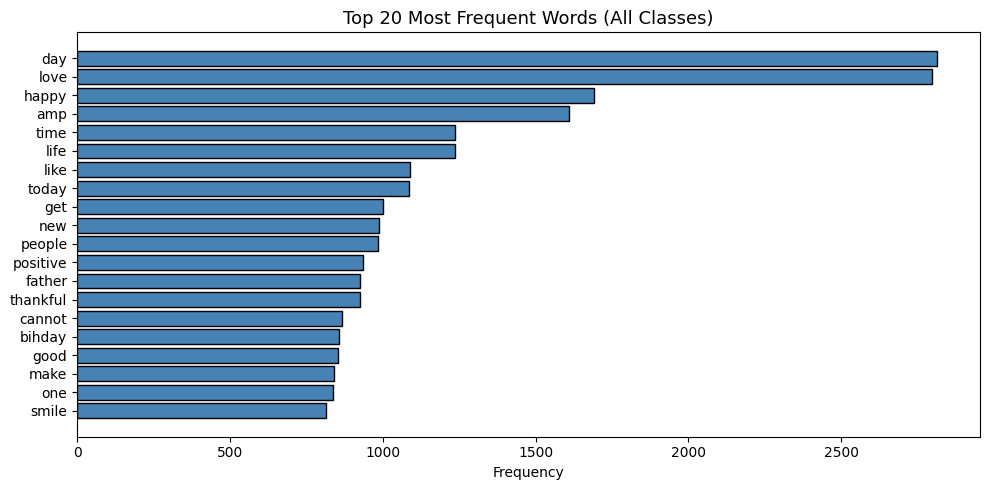

Top 20 words: [('day', 2813), ('love', 2796), ('happy', 1691), ('amp', 1608), ('time', 1235), ('life', 1235), ('like', 1088), ('today', 1086), ('get', 1000), ('new', 988), ('people', 985), ('positive', 935), ('father', 925), ('thankful', 925), ('cannot', 867), ('bihday', 856), ('good', 853), ('make', 842), ('one', 837), ('smile', 813)]


In [12]:
# ── 5.3 Top-20 Most Frequent Words ───────────────────────────────────────────
words     = all_text.split()
top_words = Counter(words).most_common(20)

words_list, freq_list = zip(*top_words)
plt.figure(figsize=(10, 5))
plt.barh(words_list[::-1], freq_list[::-1], color='steelblue', edgecolor='black')
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Words (All Classes)', fontsize=13)
plt.tight_layout()
plt.show()

print('Top 20 words:', top_words)

## 6 · Prepare Features & Labels

In [13]:
# Labels are already 0/1 — no encoding needed
X = train_df['cleaned_tweet'].values
y = train_df['label'].values

# 80 / 20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train samples : {len(X_train)}')
print(f'Test  samples : {len(X_test)}')
print(f'Train label dist: {Counter(y_train)}')
print(f'Test  label dist: {Counter(y_test)}')

Train samples : 25569
Test  samples : 6393
Train label dist: Counter({0: 23775, 1: 1794})
Test  label dist: Counter({0: 5945, 1: 448})


## 7 · Tokenisation & Padding

In [14]:
VOCAB_SIZE   = 10000
OOV_TOKEN    = '<OOV>'

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)
tokenizer.fit_on_texts(X_train)

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Dynamic padding – use 95th-percentile sequence length
seq_lens     = [len(s) for s in X_train_seq]
PADDING_LEN  = int(np.percentile(seq_lens, 95))
coverage     = sum(1 for s in seq_lens if s <= PADDING_LEN) / len(seq_lens)

print('Sequence statistics:')
print(f'  Vocabulary size     : {len(tokenizer.word_index):,}')
print(f'  95th-pct length     : {PADDING_LEN} tokens  (covers {coverage:.1%} of train)')
print(f'  Max length          : {max(seq_lens)}')

X_train_pad = pad_sequences(X_train_seq, maxlen=PADDING_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=PADDING_LEN,
                             padding='post', truncating='post')

print(f'\nX_train_pad : {X_train_pad.shape}')
print(f'X_test_pad  : {X_test_pad.shape}')

Sequence statistics:
  Vocabulary size     : 32,104
  95th-pct length     : 13 tokens  (covers 97.1% of train)
  Max length          : 20

X_train_pad : (25569, 13)
X_test_pad  : (6393, 13)


## 8 · Handle Class Imbalance with Random Over-Sampling

Before resampling: Counter({0: 23775, 1: 1794})
After  resampling: Counter({0: 23775, 1: 23775})
Resampled train set size: 47,550


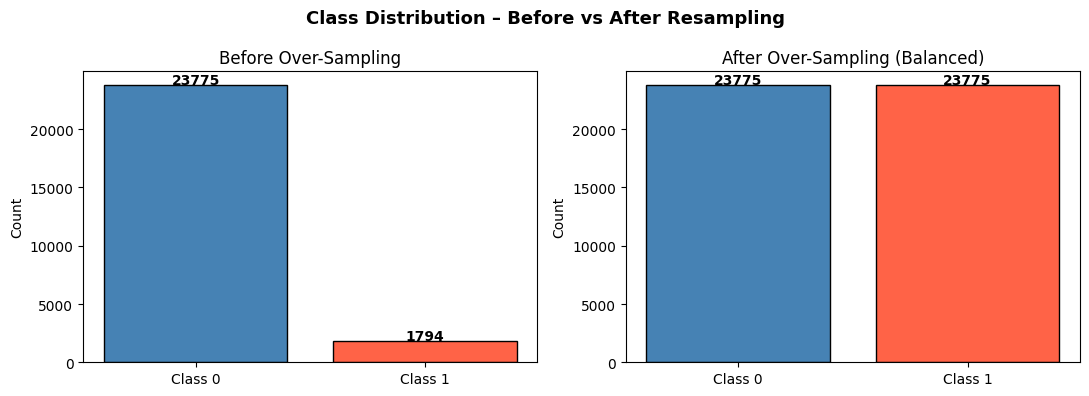

In [15]:
print('Before resampling:', Counter(y_train))

ros = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_pad, y_train)

print('After  resampling:', Counter(y_resampled))
print(f'Resampled train set size: {len(X_resampled):,}')

# Visualise new distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, counts, title in zip(
        axes,
        [Counter(y_train), Counter(y_resampled)],
        ['Before Over-Sampling', 'After Over-Sampling (Balanced)']):
    ax.bar(['Class 0', 'Class 1'], [counts[0], counts[1]],
           color=['steelblue', 'tomato'], edgecolor='black')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution – Before vs After Resampling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9 · Load Pre-trained FastText Embeddings

In [16]:
# Download FastText (300-d) – ~1 GB, takes a few minutes on first run
print('Loading FastText model …')
embedding_model = api.load('fasttext-wiki-news-subwords-300')
EMBEDDING_DIM   = 300
print('FastText loaded. Vocabulary size:', len(embedding_model.key_to_index))

Loading FastText model …
[==================================================] 100.0% 958.5/958.4MB downloaded
FastText loaded. Vocabulary size: 999999


In [21]:
# Build embedding matrix
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
found = 0
for word, idx in tokenizer.word_index.items():
    if idx < VOCAB_SIZE and word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1

coverage = found / min(VOCAB_SIZE, len(tokenizer.word_index))
print(f'Words covered by FastText embeddings: {found:,} / {min(VOCAB_SIZE, len(tokenizer.word_index)):,}  ({coverage:.1%})')

Words covered by FastText embeddings: 7,921 / 10,000  (79.2%)



## 10 · Model Training
### Global Config & Helpers

In [22]:
# Shared config
EMBED_DIM_SMALL = 128       # for Models 1 & 2
NUM_CLASSES     = 1         # binary → 1 output neuron with sigmoid
BATCH_SIZE      = 64
MAX_EPOCHS      = 30

training_times = {}

#  Stratified val split from resampled data
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for tr_idx, val_idx in sss.split(X_resampled, y_resampled):
    X_tr, X_val = X_resampled[tr_idx], X_resampled[val_idx]
    y_tr, y_val = y_resampled[tr_idx], y_resampled[val_idx]

print(f'Resampled train : {X_tr.shape}  |  val : {X_val.shape}')

#  Plotting helper
def plot_training_history(history, model_name):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc,     'bo-', label='Train Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Val   Accuracy')
    plt.title(f'{model_name} – Accuracy',  fontsize=12)
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss,     'bo-', label='Train Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Val   Loss')
    plt.title(f'{model_name} – Loss',  fontsize=12)
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

    plt.tight_layout()
    plt.show()


# Evaluation helper
def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    print(f'\n{'='*60}')
    print(f'  Evaluation – {model_name}')
    print(f'{'='*60}')

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f'Test Accuracy : {accuracy:.4f}')
    print(f'Test Loss     : {loss:.4f}')

    y_prob  = model.predict(X_test, verbose=0).flatten()
    y_pred  = (y_prob >= threshold).astype(int)

    print(f'\nClassification Report (threshold = {threshold}):')
    print(classification_report(y_test, y_pred,
                                 target_names=['Not Racist/Sexist (0)', 'Racist/Sexist (1)'],
                                 digits=4))

    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Not Racist/Sexist', 'Racist/Sexist']
    )
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix – {model_name}', fontsize=12)
    plt.tight_layout()
    plt.show()

    return accuracy, loss

print('Helpers defined.')

Resampled train : (38040, 13)  |  val : (9510, 13)
Helpers defined.



### Model 1 · Simple RNN

In [23]:
tf.random.set_seed(42)

model1 = Sequential(name='SimpleRNN', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM_SMALL,
              input_length=PADDING_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop1 = EarlyStopping(monitor='val_loss', patience=3,
                             restore_best_weights=True, verbose=1)

start = time.time()
history1 = model1.fit(
    X_tr, y_tr,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop1],
    verbose=1
)
training_times['Model 1 – Simple RNN'] = time.time() - start
print(f'\nTraining time: {training_times["Model 1 – Simple RNN"]:.1f}s')

Epoch 1/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9332 - loss: 0.1572 - val_accuracy: 0.9877 - val_loss: 0.0379
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9933 - loss: 0.0220 - val_accuracy: 0.9845 - val_loss: 0.0520
Epoch 3/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9955 - loss: 0.0140 - val_accuracy: 0.9813 - val_loss: 0.0703
Epoch 4/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9961 - loss: 0.0127 - val_accuracy: 0.9870 - val_loss: 0.0491
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

Training time: 37.8s


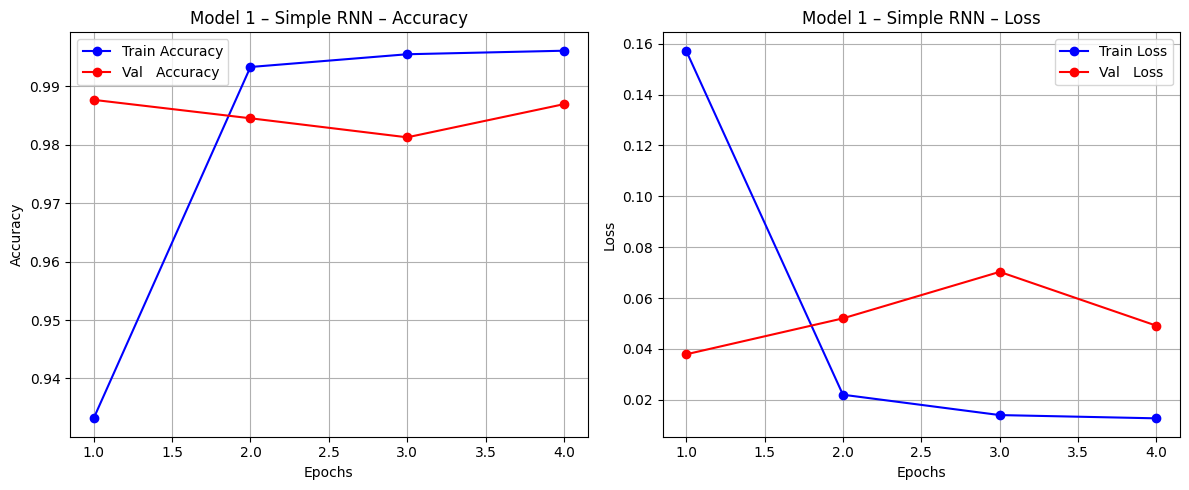


  Evaluation – Model 1 – Simple RNN
Test Accuracy : 0.9537
Test Loss     : 0.1818

Classification Report (threshold = 0.5):
                       precision    recall  f1-score   support

Not Racist/Sexist (0)     0.9669    0.9839    0.9753      5945
    Racist/Sexist (1)     0.7209    0.5536    0.6263       448

             accuracy                         0.9537      6393
            macro avg     0.8439    0.7687    0.8008      6393
         weighted avg     0.9497    0.9537    0.9509      6393



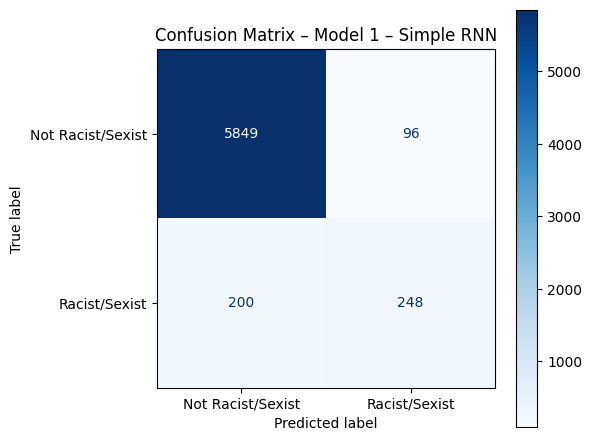

In [25]:
plot_training_history(history1, 'Model 1 – Simple RNN')
acc1, loss1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1 – Simple RNN')

### Model 2 · LSTM with Trainable Embeddings

In [26]:
tf.random.set_seed(42)

model2 = Sequential(name='LSTM_TrainableEmb', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM_SMALL,
              input_length=PADDING_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model2.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_TrainableEmb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
early_stop2 = EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True, verbose=1)
lr_sched2   = ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                  patience=3, min_lr=1e-6, verbose=1)

start = time.time()
history2 = model2.fit(
    X_tr, y_tr,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop2, lr_sched2],
    verbose=1
)
training_times['Model 2 – LSTM'] = time.time() - start
print(f'\nTraining time: {training_times["Model 2 – LSTM"]:.1f}s')

Epoch 1/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9058 - loss: 0.2134 - val_accuracy: 0.9727 - val_loss: 0.0835 - learning_rate: 5.0000e-04
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9812 - loss: 0.0564 - val_accuracy: 0.9739 - val_loss: 0.0877 - learning_rate: 5.0000e-04
Epoch 3/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9886 - loss: 0.0347 - val_accuracy: 0.9665 - val_loss: 0.1146 - learning_rate: 5.0000e-04
Epoch 4/30
594/595 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9912 - loss: 0.0268
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
595/595 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9917 - loss: 0.0247 - val_accuracy: 0.9708 - val_loss: 0.1316 - learning_rate: 5.0000e-04
Epoch 5/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9953 - loss: 0.0128 - val_accuracy: 0.9810 - val_loss: 0.1069 - learning_rate: 1.5000e-04
Epoch 6/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - ac

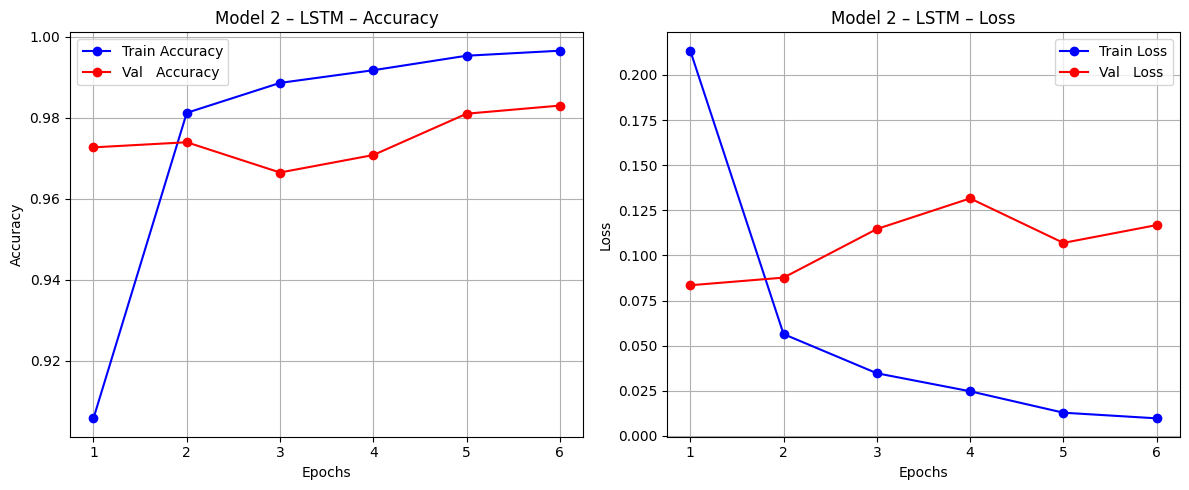


  Evaluation – Model 2 – LSTM
Test Accuracy : 0.9474
Test Loss     : 0.1720

Classification Report (threshold = 0.5):
                       precision    recall  f1-score   support

Not Racist/Sexist (0)     0.9787    0.9645    0.9715      5945
    Racist/Sexist (1)     0.6049    0.7210    0.6578       448

             accuracy                         0.9474      6393
            macro avg     0.7918    0.8427    0.8147      6393
         weighted avg     0.9525    0.9474    0.9496      6393



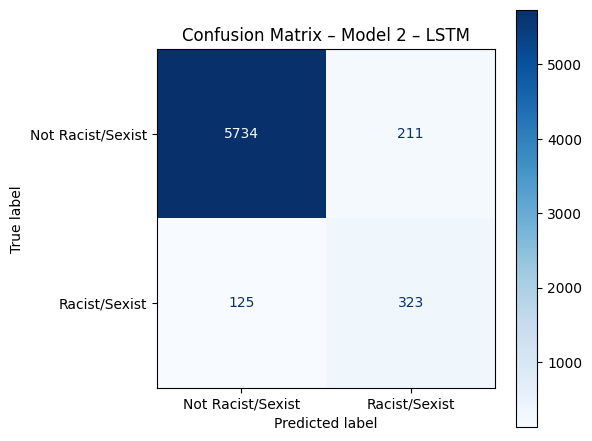

In [28]:
plot_training_history(history2, 'Model 2 – LSTM')
acc2, loss2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2 – LSTM')

### Model 3 · Bidirectional LSTM with Pre-trained FastText Embeddings

In [29]:
tf.random.set_seed(42)

model3 = Sequential(name='BiLSTM_FastText', layers=[
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              input_length=PADDING_LEN,
              trainable=False),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model3.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "BiLSTM_FastText"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,000,000 (11.44 MB)

In [30]:
early_stop3 = EarlyStopping(monitor='val_accuracy', patience=4,
                             restore_best_weights=True, verbose=1)
lr_sched3   = ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                  patience=3, min_lr=1e-6, verbose=1)

# Compute class weights for extra imbalance control
cw_vals = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_tr),
    y=y_tr
)
cw_dict = dict(enumerate(cw_vals))
print('Class weights:', cw_dict)

start = time.time()
history3 = model3.fit(
    X_tr, y_tr,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop3, lr_sched3],
    class_weight=cw_dict,
    verbose=1
)
training_times['Model 3 – BiLSTM + FastText'] = time.time() - start
print(f'\nTraining time: {training_times["Model 3 – BiLSTM + FastText"]:.1f}s')

Class weights: {0: 1.0, 1: 1.0}
Epoch 1/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 35s 54ms/step - accuracy: 0.8490 - loss: 0.3569 - val_accuracy: 0.8678 - val_loss: 0.3035 - learning_rate: 5.0000e-04
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 33s 55ms/step - accuracy: 0.8849 - loss: 0.2710 - val_accuracy: 0.8904 - val_loss: 0.2554 - learning_rate: 5.0000e-04
Epoch 3/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 33s 55ms/step - accuracy: 0.9010 - loss: 0.2290 - val_accuracy: 0.9058 - val_loss: 0.2240 - learning_rate: 5.0000e-04
Epoch 4/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9195 - loss: 0.1932 - val_accuracy: 0.9218 - val_loss: 0.1958 - learning_rate: 5.0000e-04
Epoch 5/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.9328 - loss: 0.1666 - val_accuracy: 0.9105 - val_loss: 0.2214 - learning_rate: 5.0000e-04
Epoch 6/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 34s 58ms/step - accuracy: 0.9415 - loss: 0.1476 - val_accuracy: 0.9377 - val_loss: 0.1735 - learning_rate: 5.0000e-04
Epoch 7/30
595/595 ━

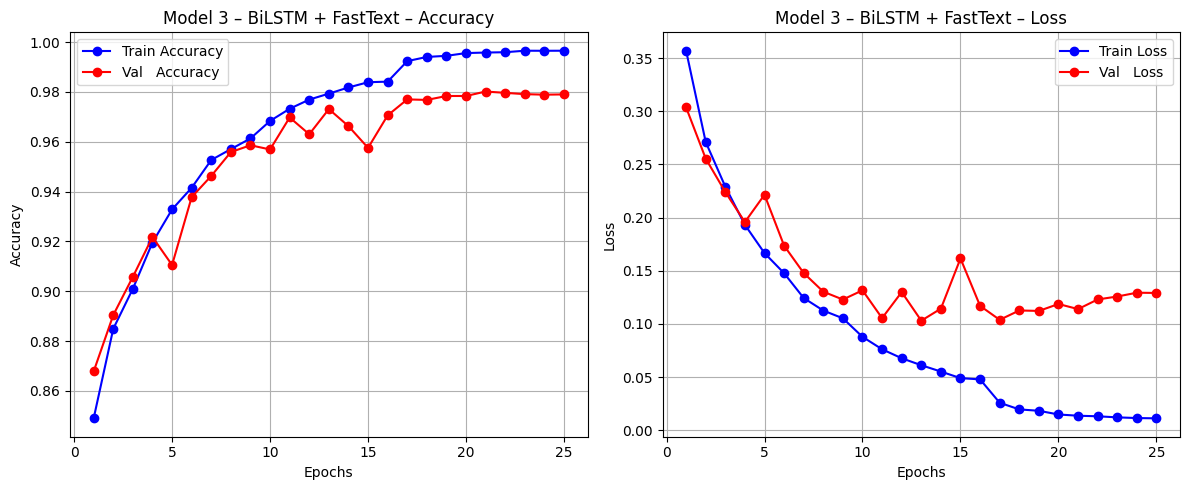


  Evaluation – Model 3 – BiLSTM + FastText
Test Accuracy : 0.9465
Test Loss     : 0.6010

Classification Report (threshold = 0.5):
                       precision    recall  f1-score   support

Not Racist/Sexist (0)     0.9730    0.9694    0.9712      5945
    Racist/Sexist (1)     0.6128    0.6429    0.6275       448

             accuracy                         0.9465      6393
            macro avg     0.7929    0.8061    0.7993      6393
         weighted avg     0.9477    0.9465    0.9471      6393



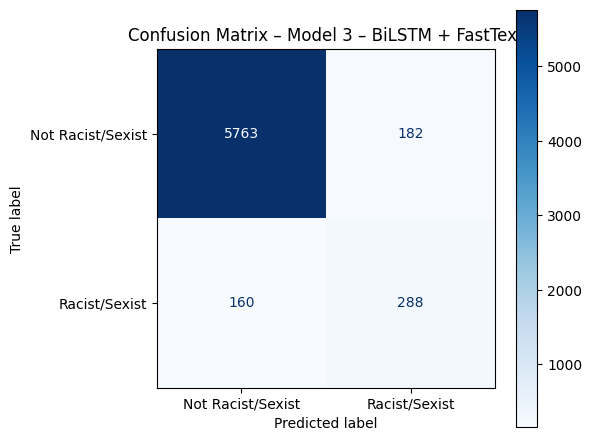

In [31]:
plot_training_history(history3, 'Model 3 – BiLSTM + FastText')
acc3, loss3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3 – BiLSTM + FastText')

## 11 · Final Model Comparison

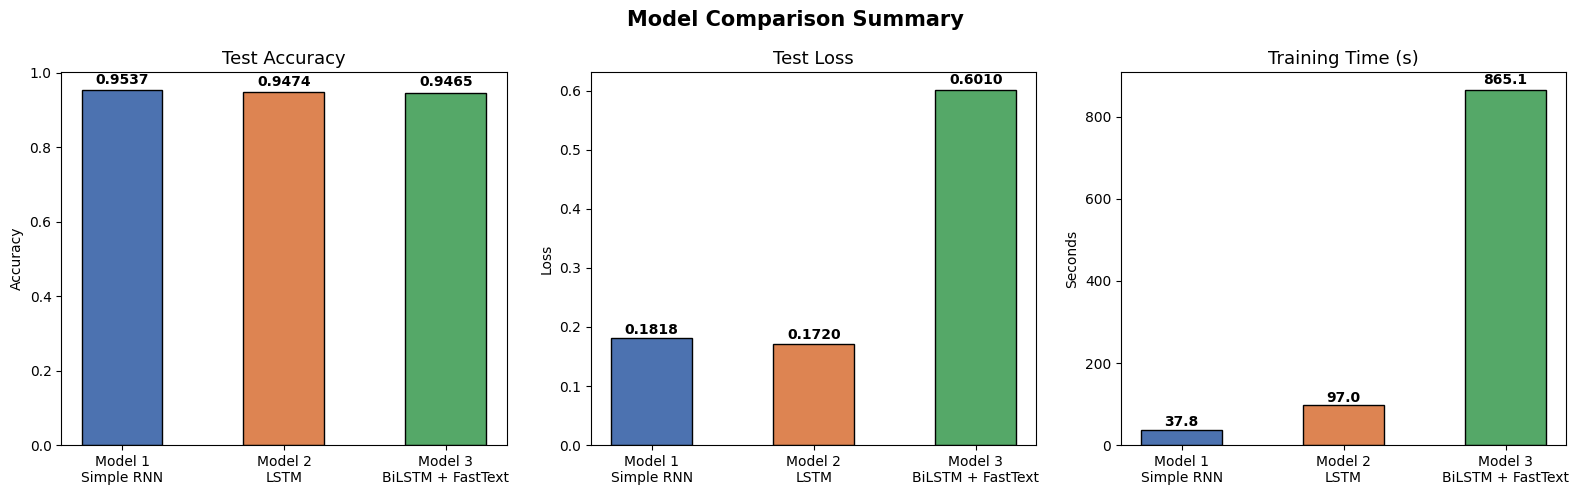


 Final Summary
Model 1 – Simple RNN                 Acc=0.9537  Loss=0.1818  Time=0.63 min
Model 2 – LSTM                       Acc=0.9474  Loss=0.1720  Time=1.62 min
Model 3 – BiLSTM + FastText          Acc=0.9465  Loss=0.6010  Time=14.42 min


In [34]:
model_names = [
    'Model 1\nSimple RNN',
    'Model 2\nLSTM',
    'Model 3\nBiLSTM + FastText'
]
accuracies  = [acc1, acc2, acc3]
losses      = [loss1, loss2, loss3]
times       = list(training_times.values())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, values, title, ylabel, fmt in zip(
        axes,
        [accuracies, losses, times],
        ['Test Accuracy', 'Test Loss', 'Training Time (s)'],
        ['Accuracy', 'Loss', 'Seconds'],
        ['.4f', '.4f', '.1f']):
    bars = ax.bar(model_names, values, color=colors, edgecolor='black', width=0.5)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f'{val:{fmt}}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Model Comparison Summary', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Final Summary')
for name, acc, loss, t in zip(
        training_times.keys(), accuracies, losses, times):
    print(f'{name:<35}  Acc={acc:.4f}  Loss={loss:.4f}  Time={t/60:.2f} min')

## 12 · Generate Predictions on Unlabelled Test Set

In [35]:
# Use the best model (Model 3) to predict on the held-out test set
test_seq     = tokenizer.texts_to_sequences(test_df['cleaned_tweet'].values)
test_pad     = pad_sequences(test_seq, maxlen=PADDING_LEN,
                              padding='post', truncating='post')

test_probs   = model3.predict(test_pad, verbose=0).flatten()
test_labels  = (test_probs >= 0.5).astype(int)

submission   = pd.DataFrame({'id': test_df['id'], 'label': test_labels})
submission.to_csv('submission_predictions.csv', index=False)

print('Predictions saved to submission_predictions.csv')
print(f'Predicted class distribution: {Counter(test_labels)}')
submission.head(10)

Predictions saved to submission_predictions.csv
Predicted class distribution: Counter({0: 15909, 1: 1288})


,id,label
0,31963,0
1,31964,1
2,31965,0
3,31966,0
4,31967,0
5,31968,0
6,31969,0
7,31970,0
8,31971,0
9,31972,0


## 13 · Interactive Demo with Gradio

In [36]:
!pip install gradio --quiet

In [37]:
import gradio as gr

CLASS_LABELS = {0: ' Not Racist / Sexist', 1: '  Racist / Sexist'}

def classify_tweet(tweet: str) -> str:
    """Clean, tokenise, pad and classify a single tweet."""
    cleaned  = clean_tweet(tweet)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=PADDING_LEN,
                             padding='post', truncating='post')
    prob     = float(model3.predict(padded, verbose=0)[0][0])
    pred_cls = int(prob >= 0.5)

    return (
        f"Prediction  : {CLASS_LABELS[pred_cls]}\n"
        f"Confidence  : {prob * 100:.1f}% (racist/sexist)"
    )


demo = gr.Interface(
    fn=classify_tweet,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Paste a tweet here …",
        label="Input Tweet"
    ),
    outputs=gr.Textbox(label="Classification Result"),
    title=" Racist / Sexist Tweet Classifier",
    description=(
        "Powered by a Bidirectional LSTM with FastText embeddings.\n"
        "Enter any tweet to classify it as Racist/Sexist (1) or Not (0)."
    ),
    examples=[
        ["I love spending time with my family #weekend"],
        ["Women should stay in the kitchen and not in the workplace"],
        ["Great game tonight! #basketball #sports"]
    ],
    theme='soft'
)

demo.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>